# Lab 02 — Vectors: Numbers with Meaning

This lab is a deeper computational companion to **Chapter 2: Vectors — Numbers with Meaning**.

The goal is not only to practice formulas. The goal is to learn how a vector becomes a mathematical object, a geometric object, and a data object at the same time.

You will:

1. write vectors in Python using NumPy;
2. draw vectors as points and arrows;
3. add, subtract, and scale vectors;
4. compute norms and distances;
5. study feature vectors and scaling;
6. compare objects in high dimensions;
7. discover a high-dimensional surprise: random vectors become more predictable in length.

## 0. Setup

Run this cell first. We use only standard scientific Python libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Vectors as arrays

In mathematics we often write

$$
v=\begin{bmatrix}3\\2\end{bmatrix}.
$$

In Python, we store this as a one-dimensional NumPy array.

In [2]:
v = np.array([3, 2])
print(v)
print("shape:", v.shape)
print("first coordinate:", v[0])
print("second coordinate:", v[1])

[3 2]
shape: (2,)
first coordinate: 3
second coordinate: 2


### Student task 1

Create a vector `weather` with six coordinates:

$$
[\text{temperature},\text{humidity},\text{wind speed},\text{pressure},\text{rain chance},\text{AQI}].
$$

Use your own numbers. Print the vector and explain in a markdown cell what each coordinate means.

In [3]:
# TODO: create your weather vector here
weather = np.array([72, 65, 12, 1015, 40, 38])
weather

array([  72,   65,   12, 1015,   40,   38])

## 2. Vectors as points

A vector in $\mathbb{R}^2$ can be drawn as a point. The coordinate values become the horizontal and vertical positions.

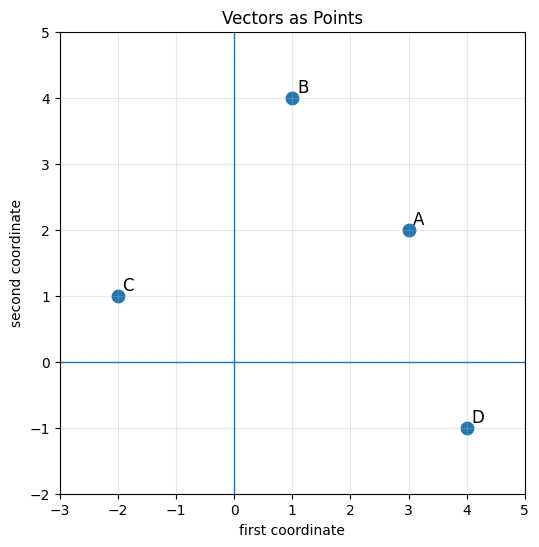

In [4]:
def plot_points(points, labels=None, title="Vectors as Points"):
    points = np.array(points)
    plt.figure(figsize=(6, 6))
    plt.scatter(points[:, 0], points[:, 1], s=80)
    if labels is not None:
        for (x, y), label in zip(points, labels):
            plt.text(x + 0.08, y + 0.08, label, fontsize=12)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    pad = 1
    plt.xlim(points[:,0].min()-pad, points[:,0].max()+pad)
    plt.ylim(points[:,1].min()-pad, points[:,1].max()+pad)
    plt.xlabel("first coordinate")
    plt.ylabel("second coordinate")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

points = np.array([[3, 2], [1, 4], [-2, 1], [4, -1]])
plot_points(points, labels=["A", "B", "C", "D"])

### Interpretation

If these points represent restaurants using

$$
[\text{price level},\text{rating}],
$$

then each point is a restaurant in a two-dimensional feature space.

If they represent locations, then each point is a physical position.

Same array. Different story.

## 3. Vectors as arrows

As an arrow, the same vector represents movement from the origin.

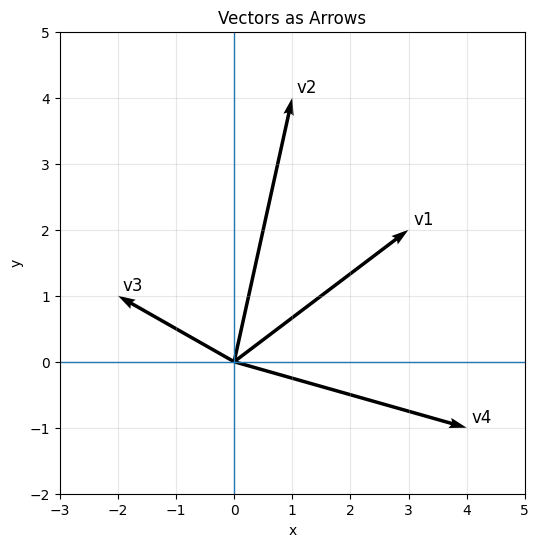

In [5]:
def plot_arrows(vectors, labels=None, starts=None, title="Vectors as Arrows"):
    vectors = np.array(vectors, dtype=float)
    if starts is None:
        starts = np.zeros_like(vectors)
    else:
        starts = np.array(starts, dtype=float)
    plt.figure(figsize=(6, 6))
    for i, (start, vec) in enumerate(zip(starts, vectors)):
        plt.quiver(start[0], start[1], vec[0], vec[1], angles="xy", scale_units="xy", scale=1)
        if labels is not None:
            end = start + vec
            plt.text(end[0] + 0.08, end[1] + 0.08, labels[i], fontsize=12)
    all_pts = np.vstack([starts, starts + vectors, [[0,0]]])
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    pad = 1
    plt.xlim(all_pts[:,0].min()-pad, all_pts[:,0].max()+pad)
    plt.ylim(all_pts[:,1].min()-pad, all_pts[:,1].max()+pad)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_arrows([[3,2], [1,4], [-2,1], [4,-1]], labels=["v1", "v2", "v3", "v4"])

## 4. Vector addition: tip-to-tail

Let

$$
u=\begin{bmatrix}2\\1\end{bmatrix},\qquad v=\begin{bmatrix}1\\3\end{bmatrix}.
$$

Then

$$
u+v=\begin{bmatrix}3\\4\end{bmatrix}.
$$

u + v = [3 4]


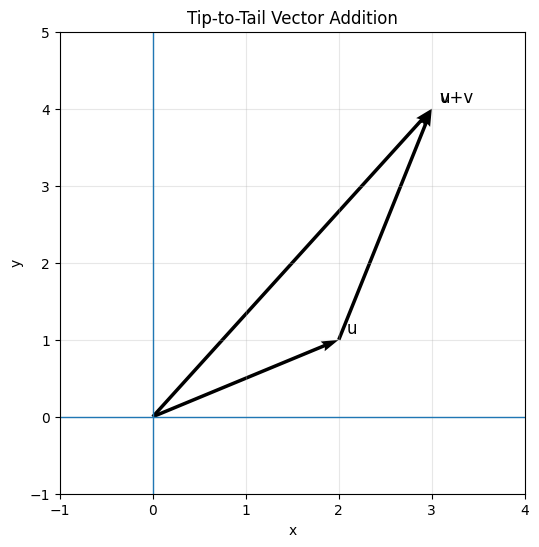

In [6]:
u = np.array([2, 1])
v = np.array([1, 3])
s = u + v
print("u + v =", s)

starts = np.array([[0,0], u, [0,0]])
vectors = np.array([u, v, s])
plot_arrows(vectors, starts=starts, labels=["u", "v", "u+v"], title="Tip-to-Tail Vector Addition")

### Student task 2

Choose two new vectors $u$ and $v$ in $\mathbb{R}^2$. Compute $u+v$ and draw the tip-to-tail picture.

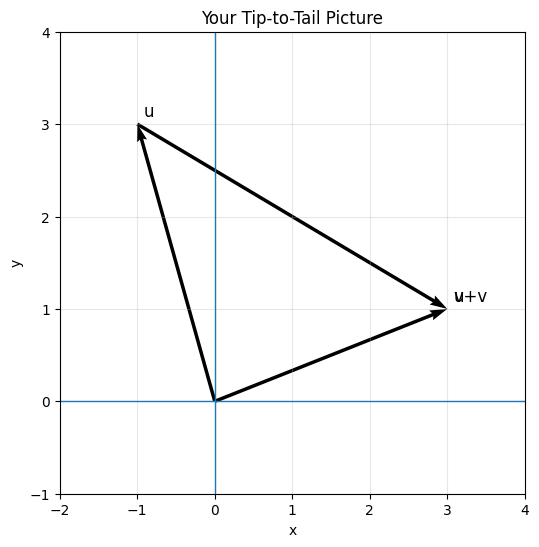

In [7]:
# TODO: change these vectors
u = np.array([-1, 3])
v = np.array([4, -2])
s = u + v

starts = np.array([[0,0], u, [0,0]])
vectors = np.array([u, v, s])
plot_arrows(vectors, starts=starts, labels=["u", "v", "u+v"], title="Your Tip-to-Tail Picture")

## 5. Scalar multiplication: intensity and direction

Multiplying a vector by a scalar changes its length. A negative scalar also reverses direction.

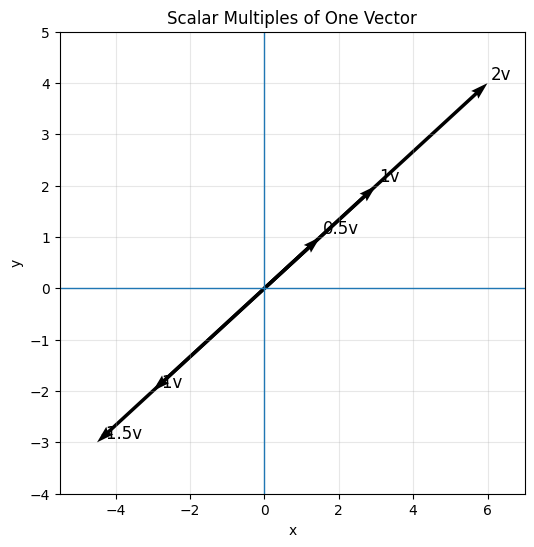

In [8]:
v = np.array([3, 2])
scalars = [-1.5, -1, 0.5, 1, 2]
scaled_vectors = np.array([c*v for c in scalars])
labels = [f"{c}v" for c in scalars]
plot_arrows(scaled_vectors, labels=labels, title="Scalar Multiples of One Vector")

### Student task 3

Use the cell below to test what happens when the scalar is:

- larger than $1$;
- between $0$ and $1$;
- equal to $0$;
- negative.

In [9]:
v = np.array([2, -1])
for c in [3, 0.25, 0, -2]:
    print(f"{c} * v =", c*v)

3 * v = [ 6 -3]
0.25 * v = [ 0.5  -0.25]
0 * v = [0 0]
-2 * v = [-4  2]


## 6. Norms and distances

The Euclidean norm is

$$
\|v\|=\sqrt{v_1^2+\cdots+v_n^2}.
$$

The distance between two vectors is

$$
\operatorname{dist}(u,v)=\|u-v\|.
$$

In [10]:
u = np.array([5, 4])
v = np.array([2, 1])

print("u-v =", u-v)
print("norm of u:", np.linalg.norm(u))
print("norm of v:", np.linalg.norm(v))
print("distance between u and v:", np.linalg.norm(u-v))

u-v = [3 3]
norm of u: 6.4031242374328485
norm of v: 2.23606797749979
distance between u and v: 4.242640687119285


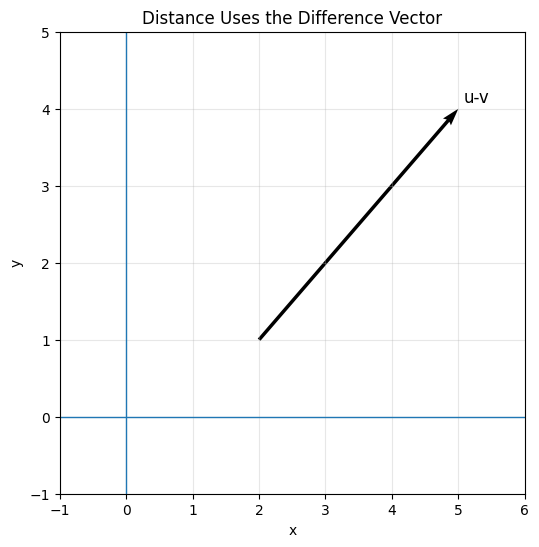

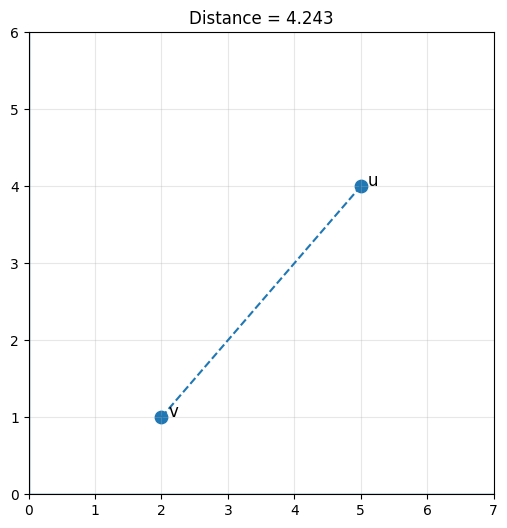

In [11]:
# Visualize distance as the arrow from v to u
u = np.array([5, 4])
v = np.array([2, 1])
d = u - v
plot_arrows([d], starts=[v], labels=["u-v"], title="Distance Uses the Difference Vector")
plt.figure(figsize=(6,6))
plt.scatter([u[0],v[0]], [u[1],v[1]], s=80)
plt.text(u[0]+.1, u[1], "u", fontsize=12)
plt.text(v[0]+.1, v[1], "v", fontsize=12)
plt.plot([v[0],u[0]], [v[1],u[1]], linestyle="--")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlim(0,7); plt.ylim(0,6)
plt.grid(True, alpha=.3)
plt.title(f"Distance = {np.linalg.norm(u-v):.3f}")
plt.show()

## 7. Feature vectors: songs as points

Now we use vectors as feature lists. Suppose each song has four features:

$$
[\text{tempo},\text{energy},\text{danceability},\text{acousticness}].
$$

Tempo is measured in beats per minute. The other features are scores between $0$ and $1$.

In [12]:
song_names = np.array(["Neon Run", "City Lights", "Quiet Rain", "Morning Air", "Fast Lane", "Soft Echo"])
songs = np.array([
    [128, 0.92, 0.88, 0.05],
    [124, 0.85, 0.81, 0.10],
    [72,  0.25, 0.35, 0.90],
    [86,  0.40, 0.50, 0.72],
    [140, 0.95, 0.70, 0.02],
    [78,  0.30, 0.42, 0.85],
])

songs

array([[128.  ,   0.92,   0.88,   0.05],
       [124.  ,   0.85,   0.81,   0.1 ],
       [ 72.  ,   0.25,   0.35,   0.9 ],
       [ 86.  ,   0.4 ,   0.5 ,   0.72],
       [140.  ,   0.95,   0.7 ,   0.02],
       [ 78.  ,   0.3 ,   0.42,   0.85]])

### 7.1 Distances without scaling

Because tempo is around $70$ to $140$, while other features are between $0$ and $1$, tempo will dominate raw Euclidean distance.

In [13]:
def pairwise_distances(X):
    n = X.shape[0]
    D = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            D[i,j] = np.linalg.norm(X[i]-X[j])
    return D

D_raw = pairwise_distances(songs)
print(np.round(D_raw, 2))

[[ 0.    4.   56.01 42.01 12.   50.01]
 [ 4.    0.   52.01 38.01 16.   46.01]
 [56.01 52.01  0.   14.   68.01  6.  ]
 [42.01 38.01 14.    0.   54.01  8.  ]
 [12.   16.   68.01 54.01  0.   62.01]
 [50.01 46.01  6.    8.   62.01  0.  ]]


### 7.2 Standardize the features

We standardize each column by subtracting its mean and dividing by its standard deviation.

This puts the features on comparable scales.

In [14]:
songs_scaled = (songs - songs.mean(axis=0)) / songs.std(axis=0)
D_scaled = pairwise_distances(songs_scaled)
print(np.round(D_scaled, 2))

[[0.   0.47 4.62 3.48 1.02 4.17]
 [0.47 0.   4.17 3.04 0.9  3.73]
 [4.62 4.17 0.   1.14 4.49 0.47]
 [3.48 3.04 1.14 0.   3.42 0.69]
 [1.02 0.9  4.49 3.42 0.   4.08]
 [4.17 3.73 0.47 0.69 4.08 0.  ]]


In [15]:
# Find closest pair after scaling
best = None
best_d = float("inf")
for i in range(len(song_names)):
    for j in range(i+1, len(song_names)):
        if D_scaled[i,j] < best_d:
            best_d = D_scaled[i,j]
            best = (song_names[i], song_names[j])

print("Closest pair after scaling:", best, "distance:", round(best_d, 3))

Closest pair after scaling: (np.str_('Neon Run'), np.str_('City Lights')) distance: 0.467


### Student task 4

Add a new song to the dataset. Compute which existing song is closest to it after scaling.

In [16]:
# TODO: change this new song
new_song = np.array([[100, 0.55, 0.60, 0.40]])

all_songs = np.vstack([songs, new_song])
all_scaled = (all_songs - all_songs.mean(axis=0)) / all_songs.std(axis=0)
new_scaled = all_scaled[-1]
old_scaled = all_scaled[:-1]

distances_to_new = np.linalg.norm(old_scaled - new_scaled, axis=1)
for name, d in zip(song_names, distances_to_new):
    print(f"{name:12s}: {d:.3f}")

print("Closest:", song_names[np.argmin(distances_to_new)])

Neon Run    : 2.511
City Lights : 2.024
Quiet Rain  : 2.494
Morning Air : 1.303
Fast Lane   : 2.465
Soft Echo   : 2.029
Closest: Morning Air


## 8. Images as vectors

A grayscale image can be viewed as a grid of numbers. It can also be flattened into one long vector.

Here we create small synthetic images so the idea is visible.

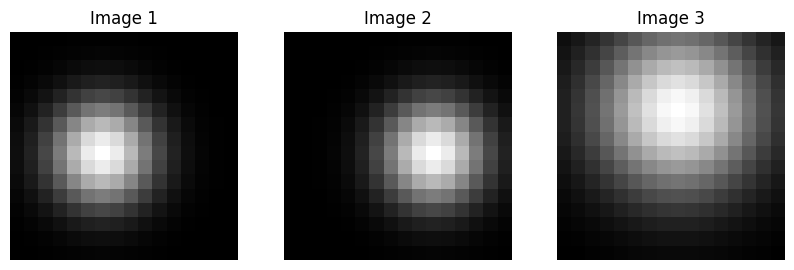

Each image vector has dimension: 256
Distance image1-image2: 4.306438460195382
Distance image1-image3: 5.121036707197923


In [17]:
def make_blob(size=16, cx=8, cy=8, sigma=3):
    y, x = np.mgrid[0:size, 0:size]
    img = np.exp(-((x-cx)**2 + (y-cy)**2)/(2*sigma**2))
    return img

img1 = make_blob(cx=6, cy=8, sigma=2.5)
img2 = make_blob(cx=10, cy=8, sigma=2.5)
img3 = make_blob(cx=8, cy=5, sigma=4.0)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, img, title in zip(axes, [img1, img2, img3], ["Image 1", "Image 2", "Image 3"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.show()

v1 = img1.reshape(-1)
v2 = img2.reshape(-1)
v3 = img3.reshape(-1)
print("Each image vector has dimension:", v1.shape[0])
print("Distance image1-image2:", np.linalg.norm(v1-v2))
print("Distance image1-image3:", np.linalg.norm(v1-v3))

### Reflection

The image is two-dimensional visually, but as data it can be treated as a vector in $\mathbb{R}^{256}$ because $16\times16=256$.

This idea becomes essential for image compression, PCA, and neural networks.

## 9. High-dimensional random vectors

Now we go beyond what can be drawn.

We generate random vectors in several dimensions and study their lengths.

In [18]:
np.random.seed(10)
dims = [2, 10, 50, 200, 1000]
num_points = 3000

summary = []
for d in dims:
    X = np.random.randn(num_points, d)
    lengths = np.linalg.norm(X, axis=1)
    summary.append([d, lengths.mean(), lengths.std(), lengths.min(), lengths.max()])

print("dimension | mean length | std length | min | max")
for row in summary:
    print(f"{row[0]:9d} | {row[1]:11.3f} | {row[2]:10.3f} | {row[3]:.3f} | {row[4]:.3f}")

dimension | mean length | std length | min | max
        2 |       1.238 |      0.640 | 0.016 | 3.771
       10 |       3.091 |      0.696 | 1.084 | 5.873
       50 |       7.026 |      0.706 | 4.791 | 9.570
      200 |      14.116 |      0.696 | 11.690 | 16.869
     1000 |      31.601 |      0.714 | 28.619 | 34.015


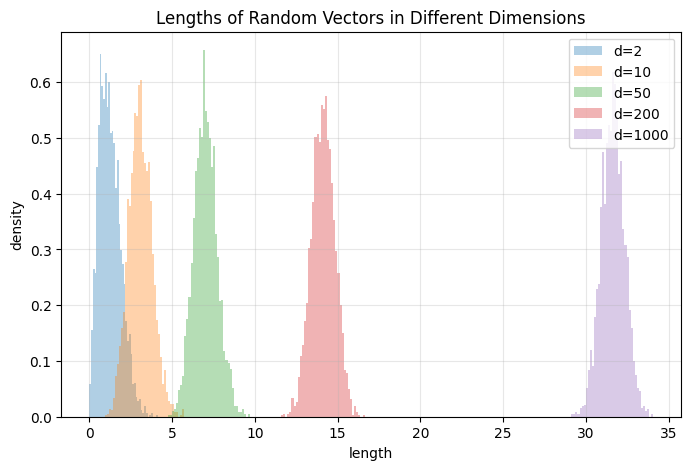

In [19]:
plt.figure(figsize=(8,5))
for d in dims:
    X = np.random.randn(num_points, d)
    lengths = np.linalg.norm(X, axis=1)
    plt.hist(lengths, bins=40, density=True, alpha=0.35, label=f"d={d}")
plt.xlabel("length")
plt.ylabel("density")
plt.title("Lengths of Random Vectors in Different Dimensions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What should you notice?

As dimension increases, lengths become concentrated around a typical scale. Random high-dimensional vectors are not spread out in length as much as our low-dimensional intuition might suggest.

This is an early glimpse of high-dimensional geometry.

## 10. Final mini-project: build a vector representation

Choose one type of object:

- restaurants;
- songs;
- courses;
- cities;
- books;
- movies;
- students' study habits;
- weather days;
- images.

Create at least six objects and at least five features. Store them as a NumPy array. Then answer:

1. What does each coordinate mean?
2. Which two objects are closest before scaling?
3. Which two objects are closest after scaling?
4. Did scaling change your interpretation?
5. Which features might be missing?
6. Is Euclidean distance the right similarity measure?

In [20]:
# Template for your final mini-project
names = np.array(["object 1", "object 2", "object 3", "object 4", "object 5", "object 6"])
X = np.array([
    [1, 2, 3, 4, 5],
    [2, 2, 3, 5, 5],
    [10, 9, 8, 7, 6],
    [9,  9, 8, 7, 7],
    [4, 1, 6, 2, 3],
    [5, 2, 6, 3, 4],
], dtype=float)

# Raw distances
D = pairwise_distances(X)

# Scaled distances
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
D_scaled = pairwise_distances(X_scaled)

print("Raw distance matrix:")
print(np.round(D, 2))
print("\nScaled distance matrix:")
print(np.round(D_scaled, 2))

Raw distance matrix:
[[ 0.    1.41 12.85 12.29  5.2   5.2 ]
 [ 1.41  0.   11.96 11.45  5.2   4.8 ]
 [12.85 11.96  0.    1.41 11.75  9.9 ]
 [12.29 11.45  1.41  0.   11.58  9.7 ]
 [ 5.2   5.2  11.75 11.58  0.    2.  ]
 [ 5.2   4.8   9.9   9.7   2.    0.  ]]

Scaled distance matrix:
[[0.   0.61 4.52 4.56 2.56 2.11]
 [0.61 0.   4.19 4.24 2.74 2.16]
 [4.52 4.19 0.   0.83 4.69 3.77]
 [4.56 4.24 0.83 0.   5.02 4.05]
 [2.56 2.74 4.69 5.02 0.   1.03]
 [2.11 2.16 3.77 4.05 1.03 0.  ]]


## Lab summary

In this lab, you learned that vectors can be computed as arrays, drawn as points or arrows, and interpreted as feature lists. You also saw that high-dimensional vectors can represent objects that cannot be drawn directly.

The main lesson is:

> A vector is a mathematical object, but its meaning comes from the coordinate story.